# Climate change — temperature anomalies vs a baseline

Climate-change communication usually centres on **anomalies** — how
much warmer or cooler a recent period is than a long-term reference.
ERA5 covers 1940–present at monthly resolution, plenty for the WMO
30-year baseline.

**Domain context.** The standard WMO climatological normal period is
1991–2020 (or 1961–1990 for older comparisons). To evaluate recent
warming we'll compute monthly 2 m temperature averaged over Europe
for two windows — a 1991–2000 decade and a 2014–2023 decade — and
show the difference.

## Step 1 — pull two decades, monthly

Box: Europe (35°–60°N, 10°W–30°E). Two retrievals — one per decade —
to keep the per-call queue request small. Each retrieval covers 120
monthly samples.

In [1]:
from pathlib import Path
from earthly import Earthly, AggregationConfig

EUR = {"lat_lim": [35.0, 60.0], "lon_lim": [-10.0, 30.0]}
VAR = {"reanalysis-era5-single-levels-monthly-means": ["2m-temperature"]}

OUT_OLD = Path("data/era5-europe-1991-2000")
OUT_NEW = Path("data/era5-europe-2014-2023")

for path, start, end in [
    (OUT_OLD, "1991-01-01", "2000-12-01"),
    (OUT_NEW, "2014-01-01", "2023-12-01"),
]:
    path.mkdir(parents=True, exist_ok=True)
    earthly = Earthly(
        data_source="ecmwf",
        temporal_resolution="monthly",
        start=start, end=end,
        variables=VAR, **EUR,
        path=str(path),
    )
    earthly.download(aggregate=AggregationConfig(freq="1MS", op="mean"))

2026-05-10 01:47:11.959 | INFO     | earthly.ecmwf.backend:download:536 - Download ECMWF reanalysis-era5-single-levels-monthly-means/2m-temperature data for period 1991-01-01 00:00:00 till 2000-12-01 00:00:00


2026-05-10 01:47:12.789 | INFO     | earthly.ecmwf.backend:_api:724 - Requesting reanalysis-era5-single-levels-monthly-means from CDS; this may take several minutes


2026-05-10 01:47:13,380 INFO Request ID is 6cb768fc-05d1-4670-a31d-a4cc379aee83


2026-05-10 01:47:13,458 INFO status has been updated to accepted


2026-05-10 01:47:46,653 INFO status has been updated to successful


...

2026-05-10 01:48:23,444 INFO status has been updated to successful


2026-05-10 01:48:23 | INFO | ecmwf.datastores.legacy_client | status has been updated to successful


2026-05-10 01:48:23 | INFO | multiurl.base | Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-05-09/e4a5eff474c75bbc96dc4d2def5860b.nc


e4a5eff474c75bbc96dc4d2def5860b.nc:   0%|          | 0.00/2.88M [00:00<?, ?B/s]

2026-05-10 01:48:25.645 | INFO     | earthly.ecmwf.backend:download:575 - ECMWF download summary: all 1 variables succeeded ([('reanalysis-era5-single-levels-monthly-means', '2m-temperature')])


## Step 2 — compute the climatology of each decade

Group the 120 monthly samples in each decade by calendar month and
average. Result: a 12-month seasonal cycle per decade.

In [2]:
import numpy as np
import pandas as pd
from pyramids.dataset import Dataset

def decade_climatology(out_dir: Path, start_year: int) -> pd.Series:
    paths = sorted((out_dir / "aggregated").glob("2m_temperature_1MS_*.tif"))
    cube = np.stack([Dataset.read_file(str(p)).read_array() for p in paths])
    site_mean = np.nanmean(cube, axis=(1, 2)) - 273.15  # to °C
    months = pd.date_range(f"{start_year}-01-01", periods=len(site_mean), freq="MS")
    s = pd.Series(site_mean, index=months)
    return s.groupby(s.index.month).mean()

old = decade_climatology(OUT_OLD, 1991)
new = decade_climatology(OUT_NEW, 2014)
anom = new - old

names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df = pd.DataFrame(
    {"1991–2000 [°C]": old.round(2).to_numpy(),
     "2014–2023 [°C]": new.round(2).to_numpy(),
     "Δ [°C]":          anom.round(2).to_numpy()},
    index=names,
)
df

,1991–2000 [°C],2014–2023 [°C],Δ [°C]
Jan,4.620000,5.210000,0.59
Feb,4.900000,6.070000,1.17
Mar,7.000000,7.750000,0.75
Apr,9.830000,10.560000,0.73
May,13.710000,14.250000,0.53
Jun,17.040001,18.379999,1.35
Jul,19.360001,20.469999,1.11
Aug,19.740000,20.490000,0.75
Sep,16.360001,17.549999,1.20
Oct,12.470000,13.690000,1.22


## Step 3 — plot the seasonal cycles and anomaly

European summer warming has accelerated more than winter — visible as
a larger anomaly in JJA than DJF on the right panel.

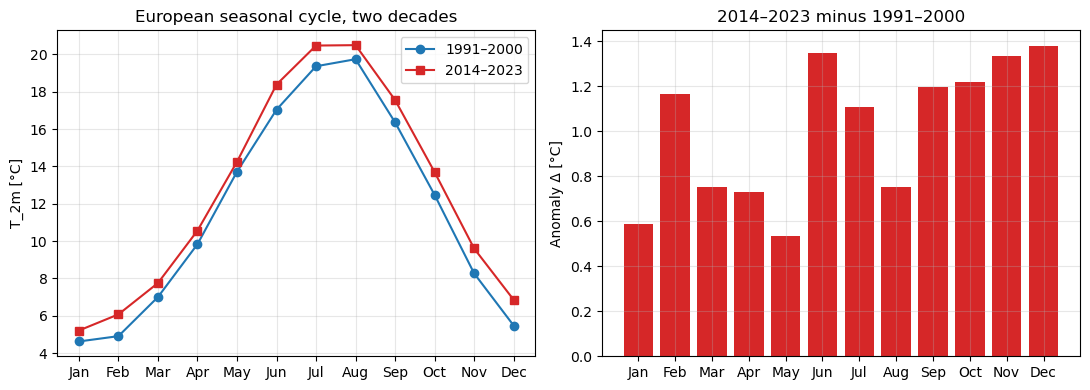

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(names, old, marker="o", label="1991–2000", color="tab:blue")
axes[0].plot(names, new, marker="s", label="2014–2023", color="tab:red")
axes[0].set_ylabel("T_2m [°C]")
axes[0].set_title("European seasonal cycle, two decades")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(names, anom, color=["tab:red" if v > 0 else "tab:blue" for v in anom])
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_ylabel("Anomaly Δ [°C]")
axes[1].set_title("2014–2023 minus 1991–2000")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Notes

- **Pick the right baseline.** WMO 1991–2020 is the current standard;
  IPCC reports use 1850–1900 (pre-industrial). The choice changes the
  numerical anomaly substantially.
- **Spatial vs temporal averaging order matters.** This notebook
  computes the per-month spatial mean first, then averages across
  years per calendar month. For a true climatological grid, do it
  the other way around — average each pixel through time first, then
  display the spatial pattern.
- **CDS-Beta data assimilation upgrades.** ERA5 was reprocessed in
  CDS-Beta with consistent satellite assimilation. The single-levels
  product has a known small jump at 1979 (start of ERA5 satellite era)
  that you should be aware of for cross-decadal comparisons.
- **For higher resolution.** ERA5-Land is 0.1° but only available
  from 1950. ERA5 single-levels at 0.25° goes back to 1940 — choose
  based on whether the spatial detail or the time depth matters more.